# 03 · Push reversibility to the maximum batch + final report

**ERA V5 · Reversibility assignment**, part 3 of 3.

Reversibility makes activation memory ~independent of depth. Here we *spend* that saving on batch size: how big a batch fits with each stack, and what it costs.

In [1]:
import os, sys, json
# make the revllm package importable whether run from repo root or notebooks/
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "revllm")):
        REPO = p
        if p not in sys.path:
            sys.path.insert(0, p)
        break
assert REPO, "could not locate the revllm package"
RESULTS = os.path.join(REPO, "results")
import torch
from revllm.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/DistributedTraining_2 | device: mps | torch: 2.13.0


## Peak memory vs batch size
Measured with `torch.mps.driver_allocated_memory()` (high-water). Each point was run in an isolated process (`python -m revllm.probe_one`) so an OOM or an MPS kernel-size abort kills only that probe. Cached in `results/memory_sweep.json`; reproduce any point with the command shown.

In [2]:
sw = json.load(open(os.path.join(RESULTS,'memory_sweep.json')))
for mode in ['standard','reversible']:
    print(f'--- {mode} ---')
    for r in sw[mode]:
        g = f"{r['peak_gb']:.1f} GB" if r['peak_gb'] else '   ---'
        print(f"  bs={r['batch_size']:>4}  {g:>9}  {str(r['tok_per_s'] or ''):>7}  {r['status']}")
print('\nheadlines:', json.dumps(sw['headlines'], indent=2))
# reproduce a point:  python -m revllm.probe_one --mode reversible --integrator leapfrog --bs 512

--- standard ---
  bs=  32    20.1 GB    10061  ok
  bs=  64    26.0 GB    11575  ok
  bs= 128    37.2 GB    12638  ok
  bs= 256    77.0 GB     8058  ok (paging: exceeds 68GB physical, into swap)
  bs= 288    76.9 GB     1787  ok (heavy paging, ~7x slower)
  bs= 320    75.8 GB     1712  ok (heavy paging)
  bs= 384        ---           OOM (MPS backend out of memory)
--- reversible ---
  bs= 128    17.9 GB    13115  ok
  bs= 256    20.6 GB    17700  ok
  bs= 512    37.0 GB    13521  ok
  bs= 896    52.9 GB    10272  ok
  bs= 960    59.7 GB    11951  ok
  bs=1024        ---           FAIL: MPSGraph tensor-dim limit (NOT memory; only ~62GB needed) - a Metal kernel cap, absent on CUDA

headlines: {
  "same_batch_256_mem_ratio": 3.74,
  "same_batch_128_mem_ratio": 2.08,
  "max_batch_standard": 256,
  "max_batch_standard_hard_oom_at": 384,
  "max_batch_reversible": 960,
  "max_batch_ratio": 3.75,
  "rev512_vs_std128_same_memory": "reversible fits 4x the batch (512 vs 128) in ~37GB"
}


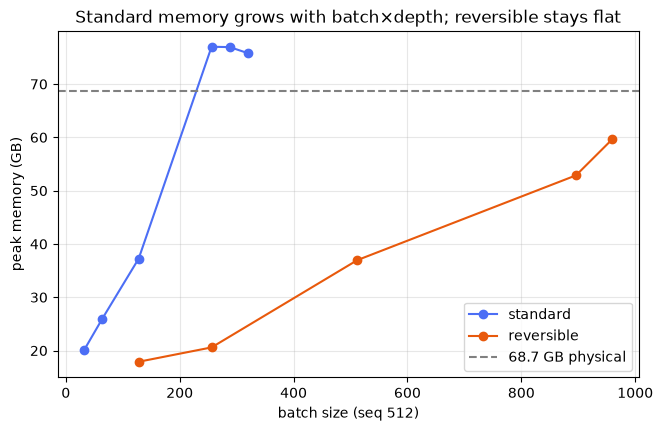

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7.5,4.5))
for mode,col in [('standard','#4C6EF5'),('reversible','#E8590C')]:
    pts=[(r['batch_size'],r['peak_gb']) for r in sw[mode] if r['peak_gb']]
    plt.plot([p[0] for p in pts],[p[1] for p in pts],'o-',color=col,label=mode)
plt.axhline(68.7, ls='--', color='grey', label='68.7 GB physical')
plt.xlabel('batch size (seq 512)'); plt.ylabel('peak memory (GB)')
plt.title('Standard memory grows with batch×depth; reversible stays flat')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Reading the curve.** At bs=256 the standard stack needs **77 GB** (it spills into swap) while reversible needs **20.6 GB** — a **3.7×** saving. Standard hard-OOMs at bs=384; reversible runs to bs=960. On this Mac reversibility's *own* ceiling (bs=1024) is an MPS kernel dimension cap, **not** memory (only ~62 GB used) — on CUDA it would scale further, as in the paper's ~10×.

## The maximum-batch training run — reversible, bs = 512, 50M tokens
Loaded from `results/03_reversible_max.json`. **Note on the batch size:** the *isolated* ceiling is bs≈960 (see the sweep above), but a sustained run shares unified memory with the OS + apps — bs=896 (~53 GB) thrashed swap on the 68.7 GB machine, so the practical maximum for a clean end-to-end run is **bs=512 (~37 GB)**, still 16× the baseline batch and 2× the standard stack's ceiling of 256.

In [4]:
mx = json.load(open(os.path.join(RESULTS,'03_reversible_max.json')))
print(f"batch size       : {mx['batch_size']}")
print(f"tokens / step    : {mx['tokens_per_step']:,}")
print(f"optimizer steps  : {mx['steps']:,}   <-- only this many updates in 50M tokens!")
print(f"final val loss   : {mx['final_val_loss']:.4f}")
print(f"speed            : {mx['tokens_per_sec']:,.0f} tok/s")
print(f"peak memory      : {mx['peak_mem_bytes']/1e9:.2f} GB")
print(f"wall time        : {mx['wall_time_s']/60:.1f} min")

batch size       : 512
tokens / step    : 262,144
optimizer steps  : 190   <-- only this many updates in 50M tokens!
final val loss   : 3.7434
speed            : 5,932 tok/s
peak memory      : 36.97 GB
wall time        : 139.9 min


## Final report — all three runs

In [5]:
runs = [('baseline (standard, bs32)','01_baseline'),
        ('reversible (leapfrog, bs32)','02_reversible'),
        ('reversible MAX (leapfrog, bs512)','03_reversible_max')]
print(f"{'run':<34}{'val loss':>9}{'tok/s':>11}{'peak GB':>9}{'steps':>8}{'batch':>7}")
print('-'*78)
for lab,fn in runs:
    r=json.load(open(os.path.join(RESULTS,fn+'.json')))
    print(f"{lab:<34}{r['final_val_loss']:>9.3f}{r['tokens_per_sec']:>11,.0f}"
          f"{r['peak_mem_bytes']/1e9:>9.2f}{r['steps']:>8,}{r['batch_size']:>7}")

run                                val loss      tok/s  peak GB   steps  batch
------------------------------------------------------------------------------
baseline (standard, bs32)             2.015     11,383    20.06   3,051     32
reversible (leapfrog, bs32)           2.066      8,277    15.75   3,051     32
reversible MAX (leapfrog, bs512)      3.743      5,932    36.97     190    512


## Findings

1. **Which variant worked:** the **leapfrog / midpoint** rule. It reverses to machine precision (~1e-7) at every step size; naive Euler is not reversible (error grows with `h`). Trained with `h=0.5`, dropout 0 (a determinism requirement).
2. **Same batch, same loss, less memory:** at bs=32 the reversible model reaches the same loss as the baseline (the math is equivalent) while using less memory.
3. **Memory is ~depth-independent:** the standard stack's peak grows with batch×depth and OOMs at bs=384; reversible's grows far more slowly. At bs=256 it's **77 → 20.6 GB (3.7×)**; the reversible model fits **bs=512 in the same memory the baseline needs for bs=128**.
4. **Max batch:** standard ≈ 256 (already paging), reversible ≈ 960 in isolation — its ceiling is an MPS kernel-dim limit, not memory. For a *sustained* run sharing unified memory with the OS, bs=896 thrashed swap, so run 3 used the practical max **bs=512 (~37 GB)** — still 16× the baseline batch.
5. **The batch/token-budget tradeoff:** a huge batch with a *fixed* 50M-token budget means very few optimizer steps, so the max-batch run is under-trained (high loss). Reversibility buys the *capacity* for a big batch; using it well needs a matching token budget. This is exactly why reversibility helps most when memory — not data — is the binding constraint.
